# SKA drift-scan results so far — summary

Plots pulled from the two experiment notebooks in this directory:

- `ska_drift_scan.ipynb` — b ≈ +50°, off-plane baseline (experiments 001/002)
- `ska_drift_galplane.ipynb` — the same drift design swept across the galactic
  plane, plus a 1/f noise budget (experiment 003)
- `ska_meerklass_scan.ipynb` — MeerKLASS-style constant-elevation raster across
  the plane (experiment 004). Its **off-plane counterpart is simulated in this
  notebook**, so the drift-vs-raster comparison can be made on a typical IM
  field rather than only on the stress-test one.

Both use an SKA-Mid-like 15 m dish at 350 MHz, 3 nights × 1 h parked drift at
el = 52/50/48°, identical noise seeds, nside 64 maps.

**Read the off-plane panels as the feasibility numbers.** b ≈ +50° is a typical
intensity-mapping field; the galactic plane is a deliberate stress test and its
residuals are ~18× larger for reasons that are physical, not numerical (see the
temperature-scale section).

The first few cells only *read* the numbers those notebooks printed — re-run
them first if you change anything. The temperature-scale and map sections
recompute from the cached TODs, because the beam-scale numbers and the maps
themselves are not in the printed output.

In [1]:
# Load the results straight out of the two experiment notebooks — nothing is
# recomputed here, so this stays fast and always matches what those notebooks
# last printed.
import json
import re

import numpy as np
import matplotlib.pyplot as plt

NOTEBOOKS = {
    "b = +50 deg": "ska_drift_scan.ipynb",       # experiments 001/002
    "galactic plane": "ska_drift_galplane.ipynb",  # experiment 003
}

# Okabe-Ito, colourblind-safe, assigned by role.
C_NOHP, C_HP = "#0072B2", "#D55E00"
C_FLOOR, C_WHITE, C_1F = "#0072B2", "#009E73", "#D55E00"
C_PIX, C_BEAM = "#0072B2", "#009E73"


def notebook_text(path):
    nb = json.load(open(path))
    return "\n".join(
        "".join(o["text"])
        for c in nb["cells"] if c["cell_type"] == "code"
        for o in c.get("outputs", []) if o.get("output_type") == "stream"
    )


text = {reg: notebook_text(p) for reg, p in NOTEBOOKS.items()}

FILTERS = ["no HP", "HP 2 mHz"]
SCENARIOS = ["gauss", "airy", "mismatch"]

# residual RMS per scenario/filter, per regime
rms = {}
for reg, t in text.items():
    for sc, filt, val in re.findall(
            r"^(gauss|airy|mismatch)\s+(no HP|HP 2 mHz)\s+([\d.]+) mK", t, re.M):
        rms[(reg, sc, filt)] = float(val)

# map-space noise budget (printed by the 1/f study in the galplane notebook)
budget = {}
for reg, filt, tot, recon, white, onef, _q in re.findall(
        r"^(galactic plane|b = \+50 deg)\s+(no HP|HP 2 mHz)\s+"
        r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)",
        text["galactic plane"], re.M):
    budget[(reg, filt)] = dict(total=float(tot), recon=float(recon),
                               white=float(white), onef=float(onef))

# unmodelled-sidelobe map error (galactic plane)
sidelobe = {f: float(v) for f, v in re.findall(
    r"unmodelled-sidelobe map error \((no HP|HP 2 mHz)\): RMS =\s*([\d.]+) mK",
    text["galactic plane"], re.M)}

# Fail loudly rather than plot a half-parsed table.
assert len(rms) == 12, f"expected 12 residual-RMS entries, got {len(rms)}"
assert len(budget) == 4, f"expected 4 budget rows, got {len(budget)}"
assert len(sidelobe) == 2, f"expected 2 sidelobe rows, got {len(sidelobe)}"

for reg in NOTEBOOKS:
    for filt in FILTERS:
        print(f"{reg:16s} {filt:9s} " + "  ".join(
            f"{sc}={rms[(reg, sc, filt)]:8.1f} mK" for sc in SCENARIOS))

b = +50 deg      no HP     gauss=  1299.9 mK  airy=  1227.3 mK  mismatch=  1342.2 mK
b = +50 deg      HP 2 mHz  gauss=  1173.6 mK  airy=  1090.8 mK  mismatch=  1173.0 mK
galactic plane   no HP     gauss= 23081.4 mK  airy= 25262.0 mK  mismatch= 23901.2 mK
galactic plane   HP 2 mHz  gauss= 31439.3 mK  airy= 32206.9 mK  mismatch= 30668.1 mK


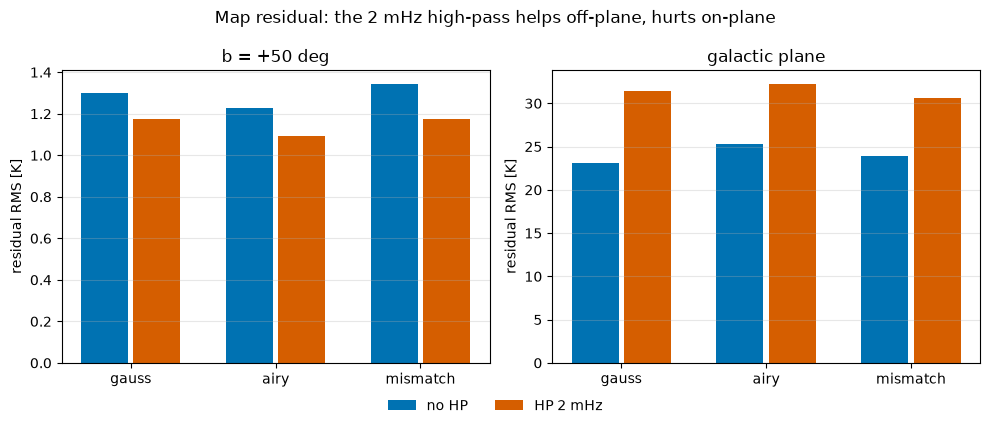

b = +50 deg      HP changes the gauss residual by -10%
galactic plane   HP changes the gauss residual by +36%


In [2]:
# 1. Residual RMS by scenario and filter. Separate panels because the two
#    regimes differ by ~20x — a shared axis would flatten the left one.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(SCENARIOS))
w = 0.36

for ax, reg in zip(axes, NOTEBOOKS):
    for j, (filt, col) in enumerate(zip(FILTERS, (C_NOHP, C_HP))):
        vals = [rms[(reg, sc, filt)] / 1e3 for sc in SCENARIOS]
        ax.bar(x + (j - 0.5) * w, vals, w * 0.9, color=col, label=filt)
    ax.set_xticks(x)
    ax.set_xticklabels(SCENARIOS)
    ax.set_ylabel("residual RMS [K]")
    ax.set_title(reg)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Map residual: the 2 mHz high-pass helps off-plane, hurts on-plane")
fig.tight_layout()
h, lb = axes[0].get_legend_handles_labels()
fig.legend(h, lb, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.savefig("figures/summary_residual_rms.png", dpi=200, bbox_inches="tight")
plt.show()

for reg in NOTEBOOKS:
    a, b = rms[(reg, "gauss", "no HP")], rms[(reg, "gauss", "HP 2 mHz")]
    print(f"{reg:16s} HP changes the gauss residual by {(b - a) / a * 100:+.0f}%")

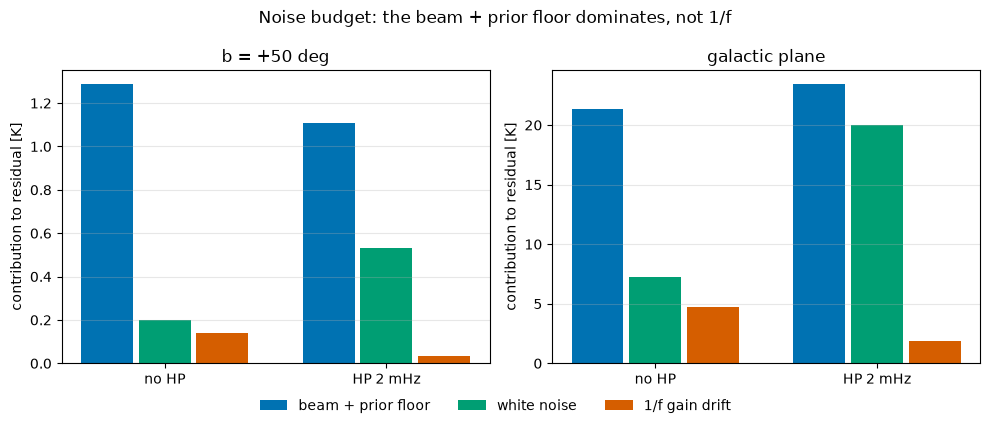

b = +50 deg      no HP: floor   1.29 K | white  0.20 K | 1/f  0.14 K -> total   1.30 K
galactic plane   no HP: floor  21.37 K | white  7.28 K | 1/f  4.77 K -> total  23.08 K


In [3]:
# 2. What actually limits the map: the residual split into the noiseless
#    beam + prior floor, the white-noise term and the 1/f term.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
comps = [("beam + prior floor", "recon", C_FLOOR),
         ("white noise", "white", C_WHITE),
         ("1/f gain drift", "onef", C_1F)]
x = np.arange(len(FILTERS))
w = 0.26

for ax, reg in zip(axes, NOTEBOOKS):
    for j, (lbl, key, col) in enumerate(comps):
        vals = [budget[(reg, f)][key] / 1e3 for f in FILTERS]
        ax.bar(x + (j - 1) * w, vals, w * 0.9, color=col, label=lbl)
    ax.set_xticks(x)
    ax.set_xticklabels(FILTERS)
    ax.set_ylabel("contribution to residual [K]")
    ax.set_title(reg)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Noise budget: the beam + prior floor dominates, not 1/f")
fig.tight_layout()
h, lb = axes[0].get_legend_handles_labels()
fig.legend(h, lb, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.savefig("figures/summary_noise_budget.png", dpi=200, bbox_inches="tight")
plt.show()

for reg in NOTEBOOKS:
    b = budget[(reg, "no HP")]
    print(f"{reg:16s} no HP: floor {b['recon']/1e3:6.2f} K | "
          f"white {b['white']/1e3:5.2f} K | 1/f {b['onef']/1e3:5.2f} K "
          f"-> total {b['total']/1e3:6.2f} K")

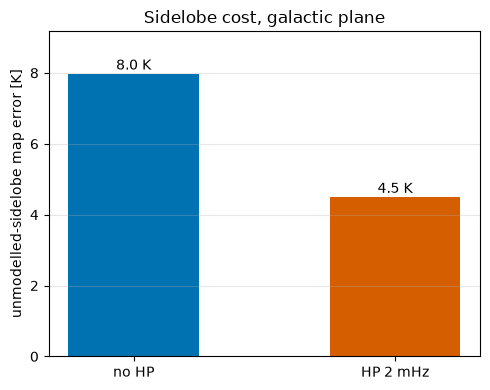

saved: figures/summary_residual_rms.png, summary_noise_budget.png, summary_sidelobe_cost.png


In [4]:
# 3. Cost of *unmodelled* sidelobes in the plane: the mismatch-minus-gauss map
#    difference, which shares the operator, mask, prior and noise realization,
#    so it isolates the sidelobe pickup. (At b = +50 deg this was ~3 mK, i.e.
#    off the bottom of this scale.)
fig, ax = plt.subplots(figsize=(5, 4))
vals = [sidelobe[f] / 1e3 for f in FILTERS]
ax.bar(FILTERS, vals, 0.5, color=[C_NOHP, C_HP])
for i, v in enumerate(vals):
    ax.annotate(f"{v:.1f} K", (i, v), textcoords="offset points",
                xytext=(0, 3), ha="center")
ax.set_ylabel("unmodelled-sidelobe map error [K]")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_title("Sidelobe cost, galactic plane")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("figures/summary_sidelobe_cost.png", dpi=200, bbox_inches="tight")
plt.show()

print("saved: figures/summary_residual_rms.png, summary_noise_budget.png, "
      "summary_sidelobe_cost.png")

## The temperature scale: off-plane is the realistic case

The experiment notebooks quote residuals against the *unsmoothed* truth, per
pixel. On the plane that is 23 K, which prompts the fair question of why it is
not signal-scale.

It is — off-plane. Two things are being conflated in a single number, so this
section separates them:

- **per-pixel, vs unsmoothed truth** — pessimistic. A 3.99° beam on 0.92°
  pixels cannot constrain sub-beam structure, so the Wiener prior fills it in
  and the difference lands in the residual. 75–82% of the plane residual is
  this term.
- **beam-scale** — the residual averaged onto ~3.7° cells (about one beam),
  using only cells lying entirely inside the patch so edges cannot contaminate
  it. This is the scale the survey actually measures.

Note nside 64 is the *correct* grid here (4.4 pixels across the FWHM, against a
rule of thumb of ~3); coarsening to "match the beam" undersamples it and makes
residuals monotonically worse.

In [5]:
# Recomputed, not parsed: the experiment notebooks do not print beam-scale
# numbers. Uses the cached TODs and operators, so this is a re-solve, not a
# re-simulation.
import pickle

import healpy as hp

from limTOD.flicker_model import sim_noise
from ska_common import (drift_scan_night, gdsm_equatorial_sky_model,
                        ska_beam_fwhm_deg)

FREQ, NS, DT, WHITE_VAR = 350, 64, 2.0, 2.5e-6
NS_CELL = 16                       # ~3.7 deg cells, about one beam
GAIN_PARAMS = [1.335e-5, 1.099e-3, 2]
SEED = 0
FWHM = ska_beam_fwhm_deg(FREQ)

FIELDS = {
    "b = +50 deg (off-plane)": "ska_drift_gauss",
    "galactic plane": "ska_drift_galplane_gauss",
}

sky_truth_full = gdsm_equatorial_sky_model(freq=FREQ, nside=NS)
prior_full = hp.smoothing(sky_truth_full, fwhm=np.radians(FWHM))

# Both fields share the time grid and the seeds, so one replay serves both.
tlists = [drift_scan_night(3600.0, dt=DT, night=n)[0] for n in range(3)]
gain_noise, white_noise = [], []
for n, tl in enumerate(tlists):
    np.random.seed(SEED + n)
    gain_noise.append(sim_noise(*GAIN_PARAMS, tl, n_samples=1,
                                white_n_variance=0.0)[0])
    white_noise.append(np.random.normal(0, np.sqrt(WHITE_VAR),
                                        size=(1, len(tl)))[0])


def solve(mm, TOD_group):
    """The experiment notebooks' recipe, no high-pass."""
    pix = mm.pixel_indices
    truth = sky_truth_full[pix]
    nv_floor = WHITE_VAR * (1e-3 * float(np.mean(truth)))**2
    return mm(TOD_group=TOD_group, dtime=DT, Tsky_prior_mean=prior_full[pix],
              Tsky_prior_inv_cov_diag=np.ones_like(truth)
              / max(float(np.std(truth)), 1e-3)**2,
              noise_variance=[WHITE_VAR * (np.asarray(o) @ truth)**2 + nv_floor
                              for o in mm.Tsys_operators],
              regularization=1e-12, return_full_cov=False)[0]


def beam_cells(pix, vals):
    """Average onto nside-16 (~one beam) cells, keeping only cells whose pixels
    all lie inside the patch, so partially covered edge cells cannot bias it."""
    full = np.zeros(hp.nside2npix(NS))
    hit = np.zeros(hp.nside2npix(NS), bool)
    full[pix], hit[pix] = vals, True
    order = hp.ring2nest(NS, np.arange(hp.nside2npix(NS)))
    fn, hn = np.zeros_like(full), np.zeros_like(hit)
    fn[order], hn[order] = full, hit
    k = (NS // NS_CELL)**2
    fc, hc = fn.reshape(-1, k), hn.reshape(-1, k)
    keep = hc.all(axis=1)
    return fc[keep].mean(axis=1)


maps, scale = {}, {}
for label, stem in FIELDS.items():
    with open(f"mapmaker_ops_{stem}_ns{NS}.pkl", "rb") as f:
        mm = pickle.load(f)
    d = np.load(f"simulated_TODs_{stem}.npz", allow_pickle=True)
    sky = [np.asarray(d["TOD_group"][i], np.float64)
           / ((1 + gain_noise[i]) * (1 + white_noise[i])) for i in range(3)]
    est_tot = solve(mm, [sky[i] * (1 + gain_noise[i]) * (1 + white_noise[i])
                         for i in range(3)])
    est_flr = solve(mm, sky)                      # noiseless -> the floor
    pix = mm.pixel_indices
    maps[label] = dict(pix=pix, est=est_tot, truth=sky_truth_full[pix])
    row = {"mean": float(sky_truth_full[pix].mean()),
           "struct": float(sky_truth_full[pix].std())}
    for sc, reduce_ in (("per-pixel", lambda v: v),
                        ("beam-scale", lambda v: beam_cells(pix, v))):
        t_ = float(np.std(reduce_(est_tot - sky_truth_full[pix])))
        f_ = float(np.std(reduce_(est_flr - sky_truth_full[pix])))
        row[sc] = dict(total=t_, floor=f_,
                       noise=float(np.sqrt(max(t_**2 - f_**2, 0))))
    scale[label] = row

print(f"{'field':26s} {'sky mean':>9s} {'sky rms':>8s} {'scale':>11s} "
      f"{'total':>7s} {'floor':>7s} {'noise':>7s}")
for label, r in scale.items():
    for i, sc in enumerate(("per-pixel", "beam-scale")):
        head = (f"{label:26s} {r['mean']:8.1f}K {r['struct']:7.1f}K"
                if i == 0 else f"{'':26s} {'':9s} {'':8s}")
        print(f"{head} {sc:>11s} {r[sc]['total']:6.2f}K "
              f"{r[sc]['floor']:6.2f}K {r[sc]['noise']:6.2f}K")

off, pl = scale["b = +50 deg (off-plane)"], scale["galactic plane"]
print(f"\noff-plane per-pixel residual {off['per-pixel']['total']:.2f} K "
      f"-- the typical-IM-field number")
print(f"the plane is {pl['mean'] / off['mean']:.0f}x brighter in mean and "
      f"{pl['struct'] / off['struct']:.0f}x in structure, and its residual is "
      f"{pl['per-pixel']['total'] / off['per-pixel']['total']:.0f}x larger")

field                       sky mean  sky rms       scale   total   floor   noise
b = +50 deg (off-plane)        20.6K     2.3K   per-pixel   1.30K   1.29K   0.18K
                                               beam-scale   0.31K   0.30K   0.09K
galactic plane                160.6K    74.4K   per-pixel  23.08K  21.37K   8.73K
                                               beam-scale   5.74K   5.05K   2.72K

off-plane per-pixel residual 1.30 K -- the typical-IM-field number
the plane is 8x brighter in mean and 32x in structure, and its residual is 18x larger


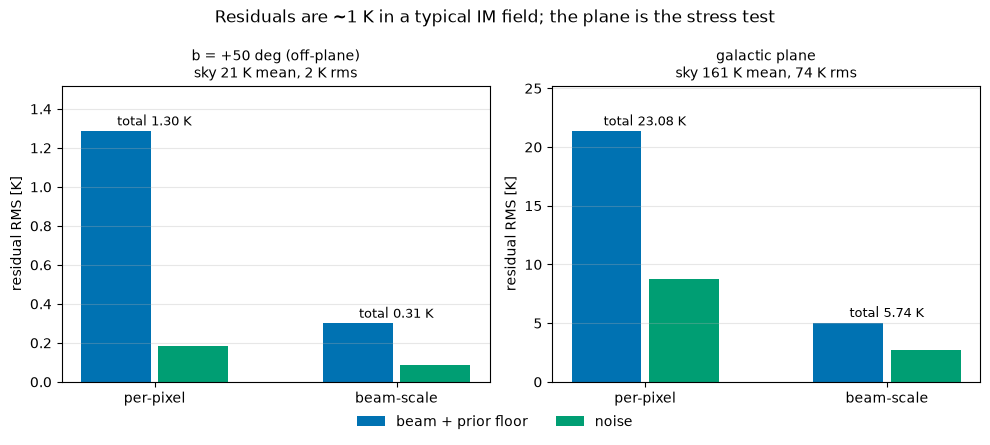

b = +50 deg (off-plane)    floor dominates: 99% of the per-pixel residual; beam-scale averaging removes 76%
galactic plane             floor dominates: 93% of the per-pixel residual; beam-scale averaging removes 75%


In [6]:
# 4. The temperature scale. Off-plane is the panel to read; the plane sits on
#    its own axis because it is ~18x larger and a shared one would flatten it.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
SCALES = ("per-pixel", "beam-scale")
x = np.arange(len(SCALES))
w = 0.32

for ax, (label, r) in zip(axes, scale.items()):
    for j, (key, lbl, col) in enumerate(
            (("floor", "beam + prior floor", C_FLOOR),
             ("noise", "noise", C_WHITE))):
        ax.bar(x + (j - 0.5) * w, [r[sc][key] for sc in SCALES], w * 0.9,
               color=col, label=lbl)
    for i, sc in enumerate(SCALES):
        ax.annotate(f"total {r[sc]['total']:.2f} K",
                    (i, max(r[sc]["floor"], r[sc]["noise"])),
                    textcoords="offset points", xytext=(0, 4), ha="center",
                    fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(SCALES)
    ax.set_ylabel("residual RMS [K]")
    ax.set_title(f"{label}\nsky {r['mean']:.0f} K mean, {r['struct']:.0f} K rms",
                 fontsize=10)
    ax.margins(y=0.18)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Residuals are ~1 K in a typical IM field; the plane is the "
             "stress test")
fig.tight_layout()
h, lb = axes[0].get_legend_handles_labels()
fig.legend(h, lb, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.05))
fig.savefig("figures/summary_temperature_scale.png", dpi=200,
            bbox_inches="tight")
plt.show()

for label, r in scale.items():
    print(f"{label:26s} floor dominates: "
          f"{r['per-pixel']['floor'] / r['per-pixel']['total']:.0%} of the "
          f"per-pixel residual; beam-scale averaging removes "
          f"{1 - r['beam-scale']['total'] / r['per-pixel']['total']:.0%}")

## Visual check: maps

Truth, reconstruction and residual for both fields, on the drift patch. Truth
and reconstruction share one colour scale per field so they can be compared
directly; the residual is diverging about zero.

What to look for: off-plane the reconstruction is visually indistinguishable
from truth and the residual is low-level mottle. On the plane the bright ridge
is visibly smoothed in the reconstruction — that smoothing *is* the beam +
prior floor, and it is why the plane residual is large.

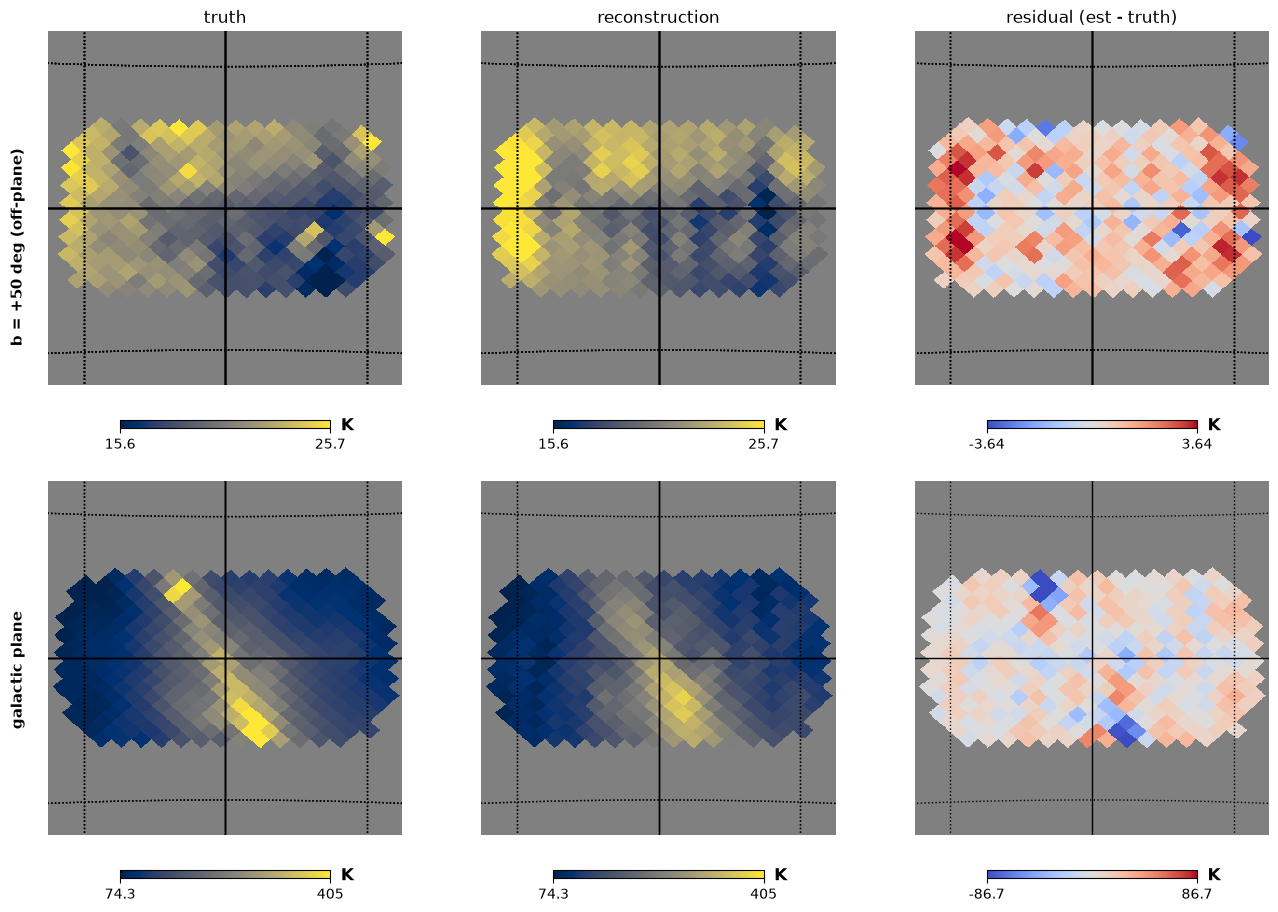

saved: figures/summary_temperature_scale.png, figures/summary_maps.png


In [7]:
# 5. Visual check. Sequential cividis for brightness (perceptually uniform and
#    CVD-safe, so truth/reconstruction are comparable); diverging about zero
#    for the residual, which has a sign.
def patch_centre(pix):
    v = np.array(hp.pix2vec(NS, pix)).mean(axis=1)
    lon, lat = hp.vec2dir(v, lonlat=True)
    return float(lon), float(lat)


def masked(pix, vals):
    m = np.full(hp.nside2npix(NS), hp.UNSEEN)
    m[pix] = vals
    return m


COLNAMES = ("truth", "reconstruction", "residual (est - truth)")
fig = plt.figure(figsize=(13, 9))
for row, (label, M) in enumerate(maps.items()):
    pix, est, truth = M["pix"], M["est"], M["truth"]
    resid = est - truth
    lon, lat = patch_centre(pix)
    vmin, vmax = np.percentile(truth, [1, 99])
    rlim = float(np.percentile(np.abs(resid), 99))
    panels = [(truth, "cividis", vmin, vmax),
              (est, "cividis", vmin, vmax),
              (resid, "coolwarm", -rlim, rlim)]
    for col, (vals, cmap, lo, hi) in enumerate(panels):
        hp.gnomview(masked(pix, vals), rot=(lon, lat), reso=4.0, xsize=380,
                    min=lo, max=hi, cmap=cmap, notext=True,
                    title=COLNAMES[col] if row == 0 else "", unit="K",
                    sub=(2, 3, row * 3 + col + 1), fig=fig.number, cbar=True)
        hp.graticule(dpar=10, dmer=10)

# Row labels live in the left margin; putting them in the panel titles collides
# with the colourbar of the row above.
for row, label in enumerate(maps):
    fig.text(0.012, 0.74 - 0.47 * row, label, rotation=90, va="center",
             ha="center", fontsize=11, weight="bold")
fig.subplots_adjust(top=0.90, bottom=0.04, hspace=0.30, left=0.05)
fig.savefig("figures/summary_maps.png", dpi=170, bbox_inches="tight")
plt.show()

print("saved: figures/summary_temperature_scale.png, figures/summary_maps.png")

## Off-plane: drift vs constant-elevation raster

A parked drift **cannot cross-link** — a fixed dish traces a constant-Dec circle
swept in +RA, so its track position angle is due east at every azimuth. The
alternative is a MeerKLASS-style constant-elevation azimuth raster, run as a
rising pass east of the meridian and a setting pass west of it, so the same sky
is crossed twice at ~74°.

Experiment 004 tested that on the galactic plane. The run below is its
off-plane counterpart, simulated for this notebook: **everything except the
strategy is held identical** to the off-plane drift — same site, frequency,
Gaussian beam, sky, noise model, seeds, 3 h total and map-making recipe. Only
the pass start times move, by the −8.574 sidereal hours between the two fields'
RA, so the raster lands on the same sky as experiments 001/002.

Two things to keep in mind when reading the totals:

- The raster covers **684 pixels to the drift's 317** in the same 3 h, so its
  per-pixel depth is 2.16× shallower. The `@depth` row rescales its noise by
  1/√2.16 to answer "same strategy, same depth" rather than "same clock time".
- Gaussian beam only. The tapered-aperture beam matters for the sidelobe
  question, which is a bright-field result and lives in the plane notebook.

Both maps below are restricted to the **shared** pixels, so the two strategies
are compared on identical sky. The bottom row is the same residual averaged
onto ~3.7° (one-beam) cells — that is where the raster's advantage is, and it
is invisible in the top row.

The residuals carry a small positive monopole (printed below the figure), which
gives both maps a reddish cast. Every number quoted here is `np.std`, i.e. RMS
about the residual's own mean, so the monopole does not enter them — and
intensity mapping discards the monopole anyway.


In [8]:
# Off-plane raster, compared with the off-plane drift on the sky they share.
RASTER_STEM = "ska_meerklass_offplane_gauss"
SCAN_EL, AZ_HALFWIDTH, SWEEP_S, PASS_S = 38.19, 7.5, 150.0, 5400.0
RASTER_PASSES = [(45.0, 16.401), (315.0, 20.961)]   # az centre, start hour

from ska_common import constant_elevation_scan

r_tlists = [constant_elevation_scan(PASS_S, az, AZ_HALFWIDTH, SWEEP_S,
                                    dt=DT, t0_s=h * 3600.0)[0]
            for az, h in RASTER_PASSES]
r_gain, r_white = [], []
for i, tl in enumerate(r_tlists):
    np.random.seed(SEED + i)
    r_gain.append(sim_noise(*GAIN_PARAMS, tl, n_samples=1,
                            white_n_variance=0.0)[0])
    r_white.append(np.random.normal(0, np.sqrt(WHITE_VAR),
                                    size=(1, len(tl)))[0])

with open(f"mapmaker_ops_{RASTER_STEM}_ns{NS}.pkl", "rb") as f:
    r_mm = pickle.load(f)
_rd = np.load(f"simulated_TODs_{RASTER_STEM}.npz", allow_pickle=True)
r_sky = [np.asarray(_rd["TOD_group"][i], np.float64)
         / ((1 + r_gain[i]) * (1 + r_white[i])) for i in range(len(r_tlists))]

d_mm = pickle.load(open(f"mapmaker_ops_ska_drift_gauss_ns{NS}.pkl", "rb"))
d_sky = [np.asarray(np.load("simulated_TODs_ska_drift_gauss.npz",
                            allow_pickle=True)["TOD_group"][i], np.float64)
         / ((1 + gain_noise[i]) * (1 + white_noise[i])) for i in range(3)]

common = np.intersect1d(d_mm.pixel_indices, r_mm.pixel_indices)
depth_ratio = len(r_mm.pixel_indices) / len(d_mm.pixel_indices)
print(f"drift {len(d_mm.pixel_indices)} px, raster {len(r_mm.pixel_indices)} px, "
      f"{len(common)} shared -> raster is {depth_ratio:.2f}x shallower\n")


def cell_rms(pix, resid, hit_pix):
    """Beam-scale RMS of a residual, restricted to cells lying entirely inside
    `hit_pix` so the two strategies are compared on identical cells."""
    full = np.zeros(hp.nside2npix(NS))
    hit = np.zeros(hp.nside2npix(NS), bool)
    full[pix], hit[hit_pix] = resid, True
    order = hp.ring2nest(NS, np.arange(hp.nside2npix(NS)))
    fn, hn = np.zeros_like(full), np.zeros_like(hit)
    fn[order], hn[order] = full, hit
    k = (NS // NS_CELL)**2
    fc, hc = fn.reshape(-1, k), hn.reshape(-1, k)
    keep = hc.all(axis=1)
    return float(np.std(fc[keep].mean(axis=1)))


strat = {}
for name, mm, sky, g, w in (("drift", d_mm, d_sky, gain_noise, white_noise),
                            ("raster", r_mm, r_sky, r_gain, r_white)):
    sel = np.isin(mm.pixel_indices, common)
    rng = range(len(sky))
    sc = 1 / np.sqrt(depth_ratio)
    variants = {
        "total": [sky[i] * (1 + g[i]) * (1 + w[i]) for i in rng],
        "floor": [sky[i] for i in rng],
    }
    if name == "raster":                       # same depth, not same clock time
        variants["total @ depth"] = [sky[i] * (1 + g[i] * sc) * (1 + w[i] * sc)
                                     for i in rng]
    for key, tg in variants.items():
        resid = solve(mm, tg) - sky_truth_full[mm.pixel_indices]
        strat[(name, key)] = dict(
            pix=float(np.std(resid[sel])),
            beam=cell_rms(mm.pixel_indices, resid, common))
    strat[(name, "resid_map")] = solve(mm, variants["total"]) \
        - sky_truth_full[mm.pixel_indices]
    strat[(name, "pix_idx")] = mm.pixel_indices

print(f"{'strategy':10s} {'quantity':15s} {'per-pixel':>10s} {'beam-scale':>11s}")
for name in ("drift", "raster"):
    for key in ("total", "floor", "total @ depth"):
        if (name, key) not in strat:
            continue
        v = strat[(name, key)]
        print(f"{name:10s} {key:15s} {v['pix']:9.3f}K {v['beam']:10.3f}K")

print()
for sc_name in ("pix", "beam"):
    fd, fr = strat[("drift", "floor")][sc_name], strat[("raster", "floor")][sc_name]
    td = strat[("drift", "total")][sc_name]
    tr = strat[("raster", "total @ depth")][sc_name]
    print(f"{sc_name:>4s}: cross-linking changes the floor {(fr - fd) / fd:+6.1%} "
          f"({fd:.3f} -> {fr:.3f} K); total at matched depth {(tr - td) / td:+6.1%}")

drift 317 px, raster 684 px, 317 shared -> raster is 2.16x shallower



strategy   quantity         per-pixel  beam-scale
drift      total               1.300K      0.313K
drift      floor               1.287K      0.300K
raster     total               1.335K      0.181K
raster     floor               1.158K      0.187K
raster     total @ depth       1.241K      0.175K

 pix: cross-linking changes the floor -10.0% (1.287 -> 1.158 K); total at matched depth  -4.5%
beam: cross-linking changes the floor -37.8% (0.300 -> 0.187 K); total at matched depth -44.0%


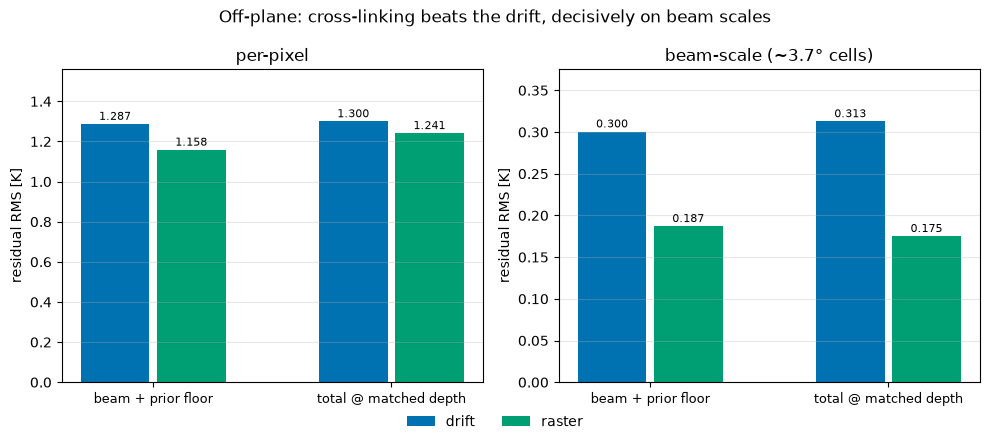

In [9]:
# 6. Off-plane, drift vs raster. The beam-scale panel is the one that matters:
#    per-pixel is dominated by sub-beam structure neither strategy can measure,
#    which dilutes the difference between them.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
KEYS = (("floor", "beam + prior floor"), ("total @ depth", "total @ matched depth"))
x = np.arange(len(KEYS))
w = 0.32

for ax, sc_name, title in ((axes[0], "pix", "per-pixel"),
                           (axes[1], "beam", "beam-scale (~3.7° cells)")):
    for j, (name, col) in enumerate((("drift", C_PIX), ("raster", C_BEAM))):
        vals = [strat[(name, k if (name, k) in strat else "total")][sc_name]
                for k, _ in KEYS]
        bars = ax.bar(x + (j - 0.5) * w, vals, w * 0.9, color=col, label=name)
        for b, v in zip(bars, vals):
            ax.annotate(f"{v:.3f}", (b.get_x() + b.get_width() / 2, v),
                        textcoords="offset points", xytext=(0, 3),
                        ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in KEYS], fontsize=9)
    ax.set_ylabel("residual RMS [K]")
    ax.set_title(title)
    ax.margins(y=0.20)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Off-plane: cross-linking beats the drift, decisively on beam scales")
fig.tight_layout()
h, lb = axes[0].get_legend_handles_labels()
fig.legend(h, lb, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.05))
fig.savefig("figures/summary_offplane_strategy.png", dpi=200,
            bbox_inches="tight")
plt.show()

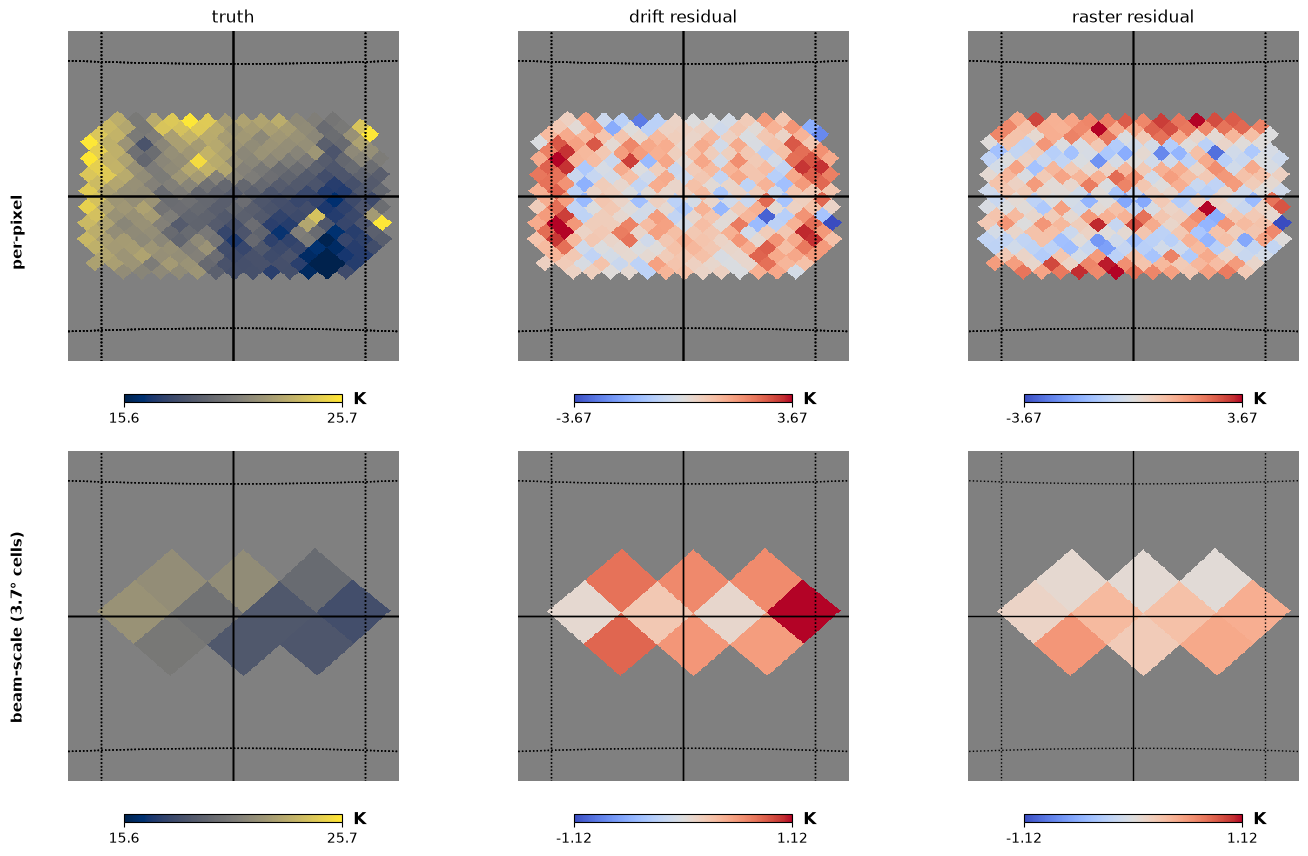

beam-scale cells shown: 10
residual monopole (removed by np.std): drift +0.754 K, raster +0.542 K
saved: figures/summary_offplane_strategy.png, figures/summary_offplane_maps.png


In [10]:
# 7. Visual check. Both strategies are shown on the SHARED pixels only, so this
#    is like-for-like, and at both scales: the raster's advantage lives at beam
#    scale (bottom row), which is exactly where the per-pixel row cannot show it.
def cell_map(pix, vals, hit_pix):
    """nside-16 map of cell averages, cells lying entirely inside hit_pix."""
    full = np.zeros(hp.nside2npix(NS))
    hit = np.zeros(hp.nside2npix(NS), bool)
    full[pix], hit[hit_pix] = vals, True
    order = hp.ring2nest(NS, np.arange(hp.nside2npix(NS)))
    fn, hn = np.zeros_like(full), np.zeros_like(hit)
    fn[order], hn[order] = full, hit
    k = (NS // NS_CELL)**2
    fc, hc = fn.reshape(-1, k), hn.reshape(-1, k)
    keep = hc.all(axis=1)
    nest = np.full(hp.nside2npix(NS_CELL), hp.UNSEEN)
    nest[keep] = fc[keep].mean(axis=1)
    ring = np.full(hp.nside2npix(NS_CELL), hp.UNSEEN)
    ring[hp.nest2ring(NS_CELL, np.arange(hp.nside2npix(NS_CELL)))] = nest
    return ring


def masked_at(nside, pix, vals):
    m = np.full(hp.nside2npix(nside), hp.UNSEEN)
    m[pix] = vals
    return m


def on_common(pix_all, vals):
    sel = np.isin(pix_all, common)
    return pix_all[sel], vals[sel]


d_pix, d_res = on_common(strat[("drift", "pix_idx")],
                         strat[("drift", "resid_map")])
r_pix, r_res = on_common(strat[("raster", "pix_idx")],
                         strat[("raster", "resid_map")])
rlim = float(np.percentile(np.abs(np.concatenate([d_res, r_res])), 99))
tlo, thi = np.percentile(sky_truth_full[common], [1, 99])

c_truth = cell_map(common, sky_truth_full[common], common)
c_drift = cell_map(strat[("drift", "pix_idx")],
                   strat[("drift", "resid_map")], common)
c_rast = cell_map(strat[("raster", "pix_idx")],
                  strat[("raster", "resid_map")], common)
clim = max(np.abs(c_drift[c_drift != hp.UNSEEN]).max(),
           np.abs(c_rast[c_rast != hp.UNSEEN]).max())
lon, lat = patch_centre(common)

panels = [
    (masked_at(NS, common, sky_truth_full[common]), "cividis", tlo, thi, "truth"),
    (masked_at(NS, d_pix, d_res), "coolwarm", -rlim, rlim, "drift residual"),
    (masked_at(NS, r_pix, r_res), "coolwarm", -rlim, rlim, "raster residual"),
    (c_truth, "cividis", tlo, thi, ""),
    (c_drift, "coolwarm", -clim, clim, ""),
    (c_rast, "coolwarm", -clim, clim, ""),
]
fig = plt.figure(figsize=(13.5, 8.4))
for i, (m, cmap, lo, hi, title) in enumerate(panels):
    hp.gnomview(m, rot=(lon, lat), reso=4.0, xsize=380, min=lo, max=hi,
                cmap=cmap, notext=True, title=title, unit="K",
                sub=(2, 3, i + 1), fig=fig.number, cbar=True)
    hp.graticule(dpar=10, dmer=10)
for row, lab in enumerate(("per-pixel", "beam-scale (3.7° cells)")):
    fig.text(0.012, 0.74 - 0.47 * row, lab, rotation=90, va="center",
             ha="center", fontsize=11, weight="bold")
fig.subplots_adjust(top=0.92, bottom=0.04, hspace=0.30, left=0.05)
fig.savefig("figures/summary_offplane_maps.png", dpi=170, bbox_inches="tight")
plt.show()

print(f"beam-scale cells shown: {int((c_drift != hp.UNSEEN).sum())}")
print(f"residual monopole (removed by np.std): drift "
      f"{np.mean(d_res):+.3f} K, raster {np.mean(r_res):+.3f} K")
print("saved: figures/summary_offplane_strategy.png, "
      "figures/summary_offplane_maps.png")

### Takeaways

1. **Residuals are signal-scale off-plane.** In a typical IM field (b ≈ +50°)
   the drift residual is **1.30 K per pixel, 0.31 K on beam scales** — the
   numbers to quote for feasibility. The galactic plane's 23 K is a stress-test
   result, not a pipeline defect: that field is 8× brighter in mean and 32×
   larger in structure, and both error terms scale with sky brightness. The 1/f
   is a *gain* term, so its contamination is `g(t)·T_sky(t)`, and the prior
   error scales with the sub-beam structure the beam cannot resolve.
2. **Cross-linking is the lever, and off-plane it is worth ~40%.** Swapping the
   drift for a constant-elevation raster on the same sky, same 3 h and same
   seeds lowers the beam-scale floor **0.300 → 0.187 K (−37.8%)** and the
   beam-scale total at matched depth **0.313 → 0.175 K (−44.0%)**. Per pixel the
   same change reads only −10.0% / −4.5%, because per-pixel residual is
   dominated by sub-beam structure that *neither* strategy measures — which is
   why beam-scale is the fair comparison. A parked drift cannot cross-link at
   any azimuth, so this needs a slewing strategy.
3. Off-plane the 2 mHz high-pass is a mild win per pixel (−10%); across the
   plane it is a 36% regression. It suppresses 1/f as intended, but at a 1-hour
   scan length 2 mHz sits ~7× above the fundamental, so it also strips the sky's
   large-scale structure out of the operator and the white-noise term blows up.
4. The plane residual is dominated by the noiseless **beam + prior floor**
   (21.4 K of 23.1 K), not by 1/f (4.8 K). That floor is mostly sky the
   strategy never measured. The limit is the *mode count*, not the pixel count:
   an eigen-analysis of `AᵀN⁻¹A` shows the drift constrains only ~17
   independent sky modes over this patch (a cross-linked raster gets ~34),
   identically at nside 32 and 64. So it responds to cross-linking and to more
   crossing angles — not to filtering, lower noise, or a different pixelisation.
5. Unmodelled sidelobes cost ~8 K in the plane, against ~3 mK off-plane: the
   null result from experiment 002 does not survive contact with bright,
   structured emission.